# 2. What the interpolation rule does to a curve

## Objective

Notebook 01 built one curve from seven quotes and used one interpolation rule
without justifying it. That choice is not innocuous. Seven quotes constrain the
discount function at seven points; everywhere else the curve is whatever the
interpolation rule says it is, and a ten year bond pays on dates that are almost
all in the "everywhere else" region.

This notebook rebuilds the same SEK government curve under all three rules the
library implements, and measures where they disagree. The point is to show that
the disagreement is muted in the zero curve and several times larger in the forward
curve, which is why forward curves are the standard diagnostic for interpolation
quality.

## Data

Identical to notebook 01: three Riksbank treasury bill quotes and four government
benchmark yields from the committed snapshot `data/snapshots/2026-07-24/`. Nothing
about the input changes between the three curves below. Only the rule for filling
the gaps changes.

## Theory

Every curve is a choice. Seven quotes constrain the discount function at seven
points; infinitely many functions pass through those points. The interpolation
rule selects one. The market data cannot tell them apart (each curve reprices the
seven instruments exactly), but they differ elsewhere.

A key difference is **locality**: how far does changing one quote propagate? A
log-linear scheme is local. Moving one pillar changes only the immediately
adjacent intervals; the curve elsewhere is unaffected. A natural cubic spline is
global: its coefficients solve a linear system coupling all knots to all others,
so moving one quote perturbs the entire curve, including regions far from the
knot. This matters to risk: a risk desk bumps one pillar to measure its exposure.
Under a local scheme the bump affects only two adjacent buckets; under a global
scheme it contaminates the whole ladder. The choice of scheme is therefore a
choice of how risk is reported, not just a technical detail.

The diagnostic for interpolation quality is the **forward curve**, not the zero
rate. The instantaneous forward is the derivative of the log discount factor:

$$ f(t) = -\frac{d \log P(0,t)}{dt} $$

Differentiation destroys one order of smoothness: if a scheme is merely
continuous then its forward may have jumps; if it is twice differentiable then
its forward is smooth. Log-linear interpolation is continuous but not
differentiable (it is piecewise linear on a compact support). Its derivative is
piecewise constant, jumping at every pillar. A cubic spline is twice
differentiable, so its forward is continuous. The monotone convex scheme of
Hagan and West is continuous and shaped to control overshoot, but deliberately
trades smoothness for control: its forward is continuous but has kinks
(discontinuous derivatives) at the knots. The zero rate, being an average of
instantaneous forwards rather than a derivative, smooths away these differences,
hiding them in aggregation. This is why the forward curve is the standard check
when assessing an interpolation method.

The **Hagan and West monotone convex scheme** constrains the forward rate to be
monotone and convex between pillars. Monotonicity prevents the forward curve from
oscillating, which would be economically incoherent; the market does not use a
model where the expected overnight rate bounces around within the curve.
Convexity prevents overshooting: the forward curve between two pillars neither
goes below the lower pillar's forward nor above the higher. This control comes at
a cost: the forward rate is only continuous, not differentiable, which is
reflected in discontinuous derivatives at the knots.

## Methodology

### The three rules

All three interpolate on $\log P(0,t)$ rather than on the discount factor or the
zero rate directly. Interpolating on $\log P$ is equivalent to interpolating on
$-t \, z(t)$, and it guarantees $P > 0$ everywhere, which interpolating on $P$
does not.

| `InterpMethod` | Rule | Implied forward curve |
|---|---|---|
| `LOG_LINEAR_DF` | Linear in $\log P$ between pillars | Piecewise constant, with jumps at
pillars |
| `CUBIC_LOG_DF` | Natural cubic spline through $\log P$ | Smooth, but can overshoot |
| `MONOTONE_CONVEX` | Hagan and West (2006) | Continuous, designed to control overshoot |

The reason a forward curve exposes the difference is that it is a derivative:

$$ f(t) = -\frac{\partial \log P(0,t)}{\partial t} $$

Differentiation destroys one order of smoothness. A rule that is continuous but
not differentiable in $\log P$, which is what linear interpolation is, produces a
forward curve that is discontinuous at every pillar. The zero rate, being an
average of forwards rather than a derivative, smooths that same behaviour back out
and hides it.

### A note on the monotone convex implementation

Hagan and West's original scheme includes an amendment that forces forward rates
to stay positive. This library deliberately omits it. Swedish and euro area
forward rates were negative for extended periods in the 2015 to 2022 window, so a
positivity constraint would have been a modelling error rather than a safeguard.
The other amendments, which control overshoot, are implemented.

In [1]:
from datetime import date

import matplotlib.pyplot as plt
import numpy as np

from yieldcurve.curves.build import sek_government_curve
from yieldcurve.curves.interpolation import InterpMethod
from yieldcurve.curves.protocol import curve_time
from yieldcurve.market.snapshot import Snapshot

ASOF = date(2026, 7, 24)
snapshot = Snapshot(ASOF)

bills = snapshot.load("riksbank_bills")
bonds = snapshot.load("riksbank_gov_benchmarks")
maturities = [
    date.fromisoformat(str(d)) for d in list(bills["maturity_date"]) + list(bonds["maturity_date"])
]
pillars = [curve_time(ASOF, m) for m in maturities]

curves = {
    method.name: sek_government_curve(snapshot, ASOF, method=method) for method in InterpMethod
}

print(f"{'tenor':>6} {'t':>8} " + "".join(f"{name:>18}" for name in curves))
for label, t in zip(list(bills["tenor"]) + list(bonds["tenor"]), pillars, strict=True):
    row = "".join(f"{100 * c.zero(t):>18.6f}" for c in curves.values())
    print(f"{label:>6} {t:>8.4f} {row}")

 tenor        t      LOG_LINEAR_DF      CUBIC_LOG_DF   MONOTONE_CONVEX
    1M   0.0849           1.958218          1.958218          1.958218
    3M   0.2521           1.996385          1.996385          1.996385
    6M   0.5041           2.060635          2.060635          2.060635
    2Y   2.0027           2.445905          2.447171          2.447227
    5Y   5.0027           2.725487          2.726679          2.727207
    7Y   7.0055           2.817624          2.818710          2.818845
   10Y  10.0082           2.992793          2.994276          2.994442


In [2]:
# This table separates the instruments into two groups, and the split is more
# informative than a uniform result would have been.
#
# **The three bill pillars are identical to six decimal places.** A bill has one cash
# flow, so its price depends on the discount factor at its own maturity and on
# nothing else. No interpolated value enters the equation, the root find has the same
# unique solution under every rule, and all three curves land on it.
#
# **The four bond pillars are not identical.** At two years the three rules give
# 2.445905, 2.447171 and 2.447227 per cent, a spread of about 0.13 basis points. This
# is not a repricing error. Each curve still reproduces its own input quote exactly:
# the bootstrap solves for whatever endpoint discount factor makes the bond price
# 100, and it succeeds in all three cases. But a two year annual coupon bond pays
# once before maturity, on a date where no quote exists, and that intermediate
# discount factor is interpolated. Change the interpolation rule and the interpolated
# coupon discount factor changes, so the endpoint discount factor has to move in the
# opposite direction to keep the total at par.
#
# The consequence is worth stating plainly, because it is easy to assume otherwise:
# a bootstrapped pillar value is not a pure market observable. It is a market
# observable *net of* whatever the interpolation rule did to the earlier cash flows.
# Only single payment instruments are free of that contamination.

In [3]:
grid = np.linspace(1 / 365, 10.0, 2000)

zeros = {name: np.array([c.zero(t) for t in grid]) for name, c in curves.items()}
fwds = {name: np.array([c.instantaneous_fwd(t) for t in grid]) for name, c in curves.items()}

reference = "MONOTONE_CONVEX"
print("maximum absolute difference against monotone convex, in basis points")
print(f"{'method':>16} {'zero':>8} {'at t':>7} {'forward':>9} {'at t':>7}")
for name in curves:
    if name == reference:
        continue
    dz = np.abs(zeros[name] - zeros[reference])
    df = np.abs(fwds[name] - fwds[reference])
    print(
        f"{name:>16} {1e4 * dz.max():>8.2f} {grid[dz.argmax()]:>7.2f}"
        f" {1e4 * df.max():>9.2f} {grid[df.argmax()]:>7.2f}"
    )

maximum absolute difference against monotone convex, in basis points
          method     zero    at t   forward    at t
   LOG_LINEAR_DF     9.52    0.86     38.18    0.51
    CUBIC_LOG_DF     2.57    1.35     11.44    2.00


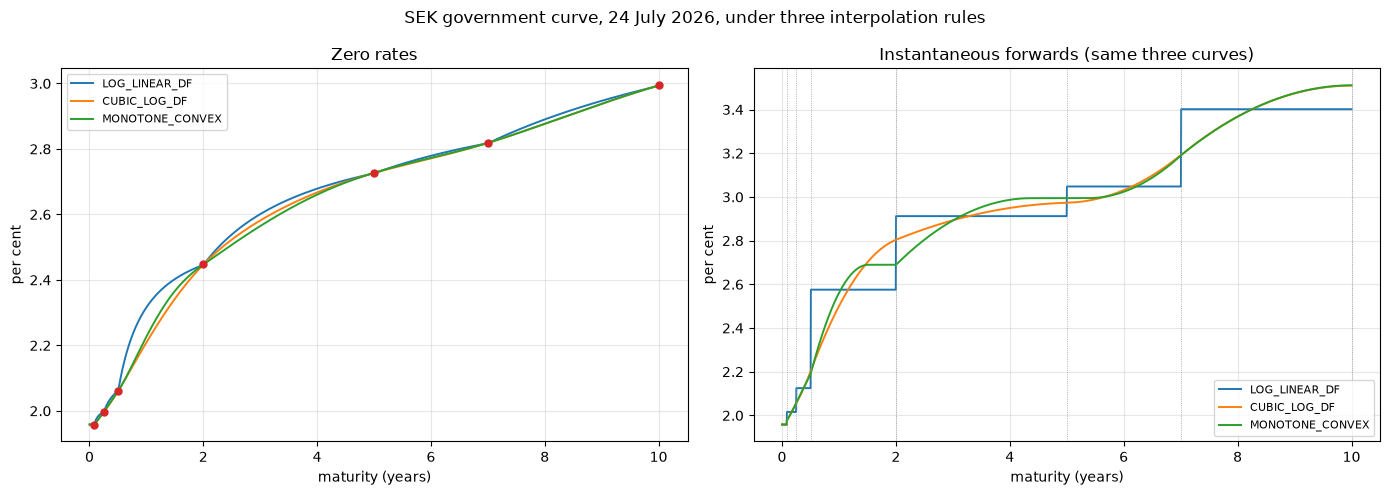

In [4]:
colours = {"LOG_LINEAR_DF": "#1f77b4", "CUBIC_LOG_DF": "#ff7f0e", "MONOTONE_CONVEX": "#2ca02c"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, series in zeros.items():
    axes[0].plot(grid, 100 * series, label=name, color=colours[name], lw=1.4)
axes[0].scatter(
    pillars,
    [100 * curves[reference].zero(t) for t in pillars],
    color="#d62728",
    zorder=3,
    s=25,
)
axes[0].set_title("Zero rates")
axes[0].set_ylabel("per cent")

for name, series in fwds.items():
    axes[1].plot(grid, 100 * series, label=name, color=colours[name], lw=1.4)
for t in pillars:
    axes[1].axvline(t, color="#999999", lw=0.6, ls=":")
axes[1].set_title("Instantaneous forwards (same three curves)")
axes[1].set_ylabel("per cent")

for ax in axes:
    ax.set_xlabel("maturity (years)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle("SEK government curve, 24 July 2026, under three interpolation rules")
fig.tight_layout()
plt.show()

In [5]:
# ## Results
#
# **The forward differences are about four times the zero differences.** Against
# monotone convex, log-linear differs by at most 9.52 basis points in zero rate
# terms and 38.18 basis points in forward terms. The cubic spline differs by 2.57
# and 11.44 basis points respectively. The ratio is the point: the same
# disagreement between two curves is roughly four times larger when measured on the
# quantity that is a derivative of the fitted object.
#
# **The disagreement is concentrated in the one region with no quote.** Every
# maximum in the table above falls between 0.51 and 2.00 years. That interval is
# precisely the gap identified in notebook 01, between the 6 month bill and the
# 2 year benchmark, left open because the 12 month bill series was discontinued
# in 2010. Where quotes are dense the rules have little room to differ; where the
# market is silent the rule is doing all the talking, and the choice of rule
# becomes a first order input.
#
# **The forward curves differ in shape, not only in level.** `LOG_LINEAR_DF`
# produces the step function visible in the right hand panel: constant forward
# within each pillar segment, discontinuous jump at each pillar. This follows
# directly from the rule. If $\log P$ is linear in $t$ on a segment then its
# derivative is constant there, so the forward is constant, and at the pillar the
# slope changes so the forward jumps. The dotted vertical lines mark the pillars,
# and every jump sits on one.
#
# **The cubic spline is smooth but not local.** A natural cubic spline through the
# log discount factors is twice differentiable, so its forward curve is
# continuous. The cost is that the spline coefficients are the solution of a
# global linear system: moving one quote changes the curve at every maturity,
# including maturities on the far side of other pillars. The overshoot this
# produces is what monotone convex is designed to suppress.
#
# ## Interpretation
#
# The economic content is that a forward curve is a statement about what the
# market implies for future short rates. A sawtooth forward curve asserts that the
# expected overnight rate is flat for three years and then jumps discontinuously
# on the day a benchmark bond happens to mature. No plausible model of monetary
# policy generates that path. The step is an artefact of the pillar grid, not
# information.
#
# This has practical consequences in three places. Products priced off forwards,
# such as caps, floors and forward starting swaps, inherit the artefact directly.
# Key rate durations, computed in notebook 05 by perturbing the curve at one
# pillar, depend on how far a bump propagates, which is a property of the
# interpolation rule. And a curve refitted daily under a non-local rule will show
# phantom moves at maturities where nothing was quoted differently.
#
# ## Limitations
#
# All three schemes assume there is a unique smooth curve to find. In fact
# infinitely many curves pass through the seven points, and only the interpolation
# rule selects one. Where data are dense the choice is inconsequential; where data
# are sparse the choice drives the output. The extrapolation beyond 10 years is
# unobserved and should not be relied upon. The forward curve is the diagnostic
# for interpolation quality, but it is not directly observable; the zero rate is
# aggregated and smooth. Disagreement in the forward curve translates to roughness
# in value and risk measurements when products are priced off instantaneous forwards
# or their derivatives.
#
# ## Regulatory context
#
# Neither Basel nor IFRS prescribes an interpolation scheme, and it would be
# surprising if they did. What the supervisory framework asks for is that the choice
# be documented and applied consistently.
#
# Under **BCBS d368** the requirement in the IRRBB standards is that a bank's
# valuation methodology be documented and its assumptions be capable of independent
# review. An interpolation rule is one of those assumptions.
#
# Under **CRR Article 105** on prudent valuation, and the EBA regulatory technical
# standards that implement it, a firm must hold an additional valuation adjustment
# for market price uncertainty. Where two defensible interpolation rules give
# materially different values for the same position, that dispersion is direct
# evidence of the uncertainty the AVA is meant to capture. The measurement made
# above, the maximum difference in basis points between rules, is the kind of number
# that supports such an estimate.
#
# Under **IFRS 13**, an input that cannot be observed in the market is a Level 3
# input regardless of how standard the technique using it is. The interpolation rule
# is unobservable in exactly this sense.
#
# ## Summary
#
# The same seven quotes were bootstrapped under log-linear, cubic spline and
# monotone convex interpolation. All three reprice their input instruments exactly.
# The three bill pillars agree to six decimal places because a bill has a single cash
# flow; the four bond pillars do not, because their intermediate coupon discount
# factors are interpolated and the solved endpoint moves to compensate.
#
# Between pillars the rules differ by up to 9.52 basis points in zero rate terms and
# 38.18 basis points in forward terms, and every one of those maxima falls in the
# 6 month to 2 year gap where no quote exists. Log-linear produces a piecewise
# constant forward curve that jumps at every pillar.
#
# Two conclusions follow. The forward curve is the diagnostic to inspect when
# assessing an interpolation scheme, because the zero curve understates the
# disagreement by roughly a factor of four. And the cost of the choice is
# concentrated where the data is thin, which is the region a valuation control
# function should be asked about first. The remaining notebooks use monotone convex
# throughout.